# Vessel Segmentation with VascX
This notebook loads the VascX model and performs vessel segmentation on 3 random images from Domain A and Domain B.

In [1]:
import os
import random
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from rtnls_inference import SegmentationEnsemble

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

<frozen importlib._bootstrap_external>:1061: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Using device: cpu


In [4]:
# Setup Paths and Data
from eval_utils import get_test_images, plot_comparison
from pathlib import Path

DATA_DIR = '../datasets/dlri/aligned'
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

chosen_A, chosen_B = get_test_images(DATA_DIR, num_images=3)
print('Selected A images:', [p.name for p in chosen_A])
print('Selected B images:', [p.name for p in chosen_B])

Selected A images: ['7330_Complete_L_0.png', '1038_Anomalous_R_0.png', '1010_Complete_R_0.png']
Selected B images: ['7330_Complete_L_0.png', '1038_Anomalous_R_0.png', '1010_Complete_R_0.png']


In [5]:
# Load VascX Model
model_path = Path('models/vessels/vessels_july24.pt')
print(f'Loading model from {model_path}...')

vessel_ensemble = SegmentationEnsemble.from_torchscript(model_path).to(device)

Loading model from models/vessels/vessels_july24.pt...


In [6]:
# Format data for rtnls_inference
data_A = [{'id': f'A_{p.stem}', 'image': str(p)} for p in chosen_A]
data_B = [{'id': f'B_{p.stem}', 'image': str(p)} for p in chosen_B]

# Run segmentation (handles preprocessing internally)
print('Running inference on Domain A...')
vessel_ensemble.predict(data_A, dest_path=RESULTS_DIR)

print('Running inference on Domain B...')
vessel_ensemble.predict(data_B, dest_path=RESULTS_DIR)


Running inference on Domain A...


  0%|          | 0/1 [00:00<?, ?it/s]/home/rameshk/.local/lib/python3.14/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/rameshk/.local/lib/python3.14/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/tor

Running inference on Domain B...


100%|██████████| 1/1 [04:29<00:00, 269.08s/it]


,id,output_path,output_kind,output_space,preprocessed_height,preprocessed_width,prediction_height,prediction_width
0,B_7330_Complete_L_0,results/B_7330_Complete_L_0.png,mask,preprocessed,1024,1024,1024,1024
1,B_1038_Anomalous_R_0,results/B_1038_Anomalous_R_0.png,mask,preprocessed,1024,1024,1024,1024
2,B_1010_Complete_R_0,results/B_1010_Complete_R_0.png,mask,preprocessed,1024,1024,1024,1024


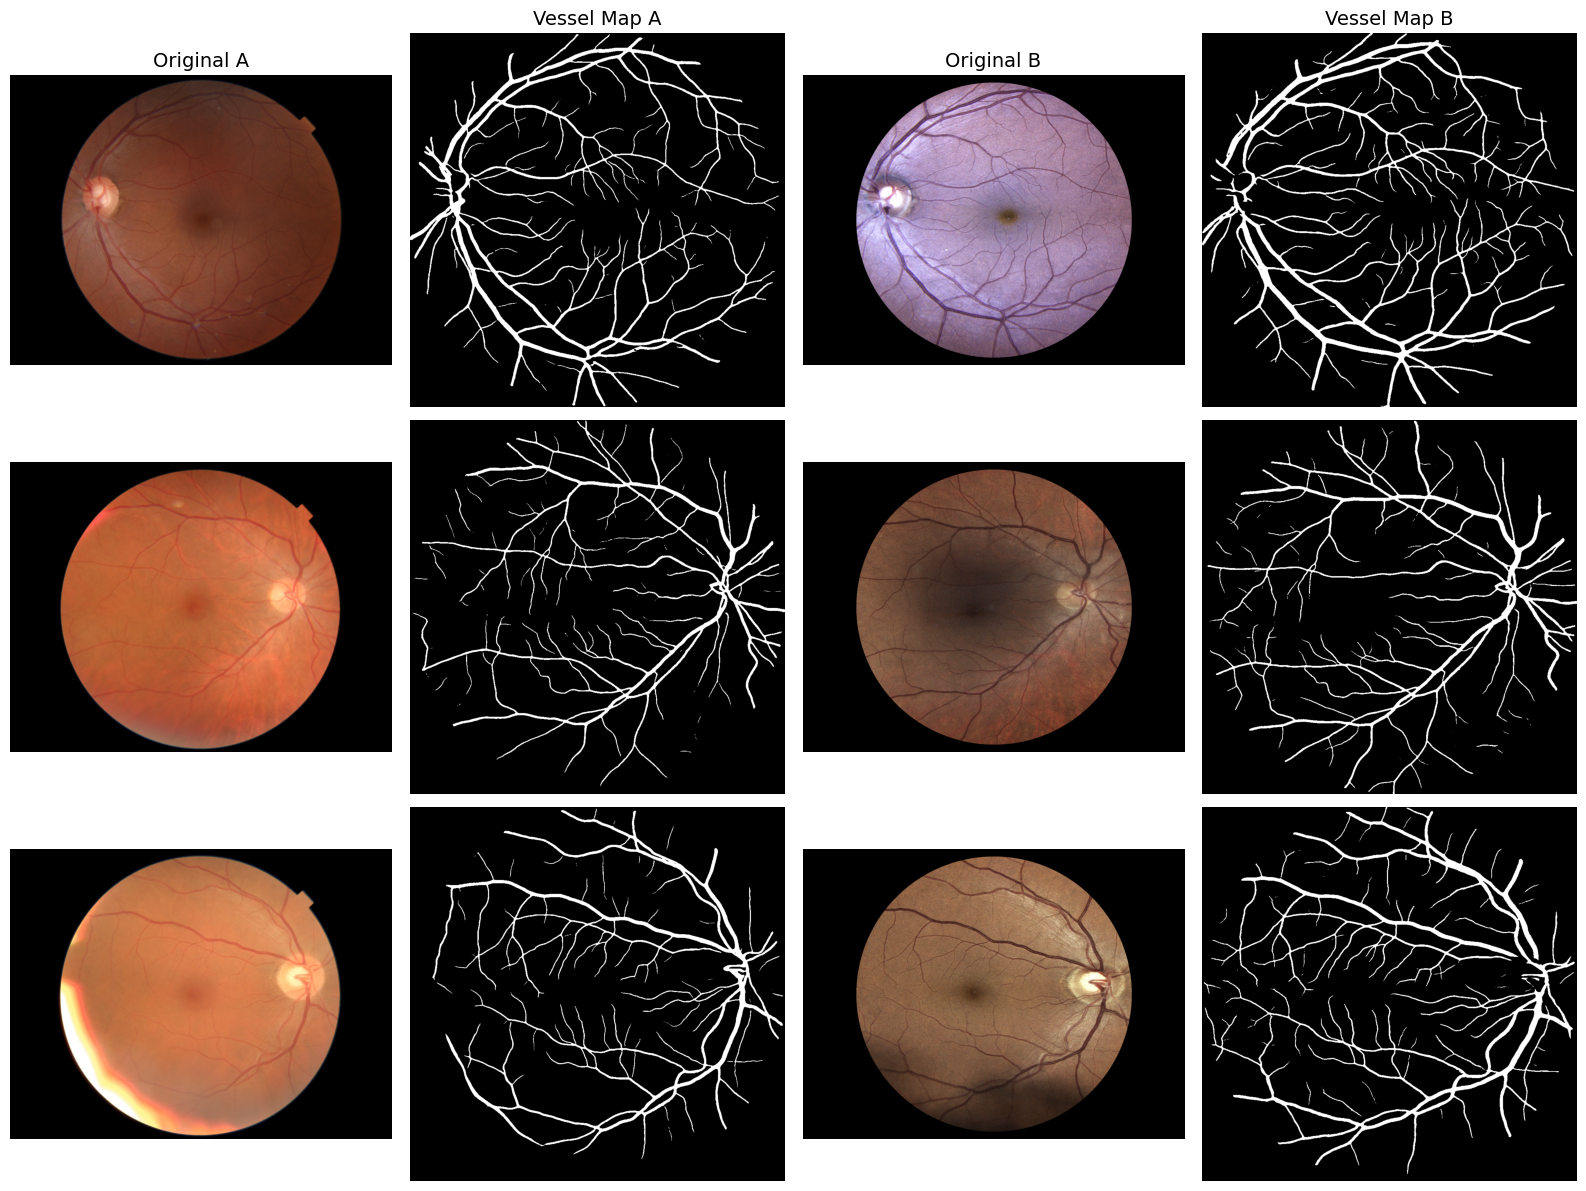

In [7]:
# Load Vessel Maps from Disk (VascX prediction saves to disk)
import cv2
preds_A = [cv2.imread(str(RESULTS_DIR / f'A_{p.stem}.png'), cv2.IMREAD_GRAYSCALE) for p in chosen_A]
preds_B = [cv2.imread(str(RESULTS_DIR / f'B_{p.stem}.png'), cv2.IMREAD_GRAYSCALE) for p in chosen_B]

save_path = RESULTS_DIR / 'vascx_comparison_plot.png'
plot_comparison(chosen_A, chosen_B, preds_A, preds_B, save_path)
print(f'Saved visualization to {save_path}')